In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xarray as xr

In [ ]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)

In [ ]:
# Load TC size files from SyCLoPS
files ={
    'era5deg1': '../final_track_file/ERA5deg1_PIKE.csv',
    'era5': '../final_track_file/ERA5_PIKE.csv',
}

dfsize = {}
for name, path in files.items():
    df = pd.read_csv(path,keep_default_na=False)
    dfsize[name] = df

In [ ]:
# Load ZU track files
old_files = {
    'era5o': '../classified_track/zu_tctrack/era5o_tracks_olds.csv',
    'era5deg1o': '../classified_track/zu_tctrack/era5deg1o_tracks_olds.csv'
}

# Load and clean CSVs
dfo_tc = {}
for name, path in old_files.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"lon": "LON", "lat": "LAT", "track_id": "TID"})
    df=df[df.year.between(1988, 2014)]
    dfo_tc[name] = df

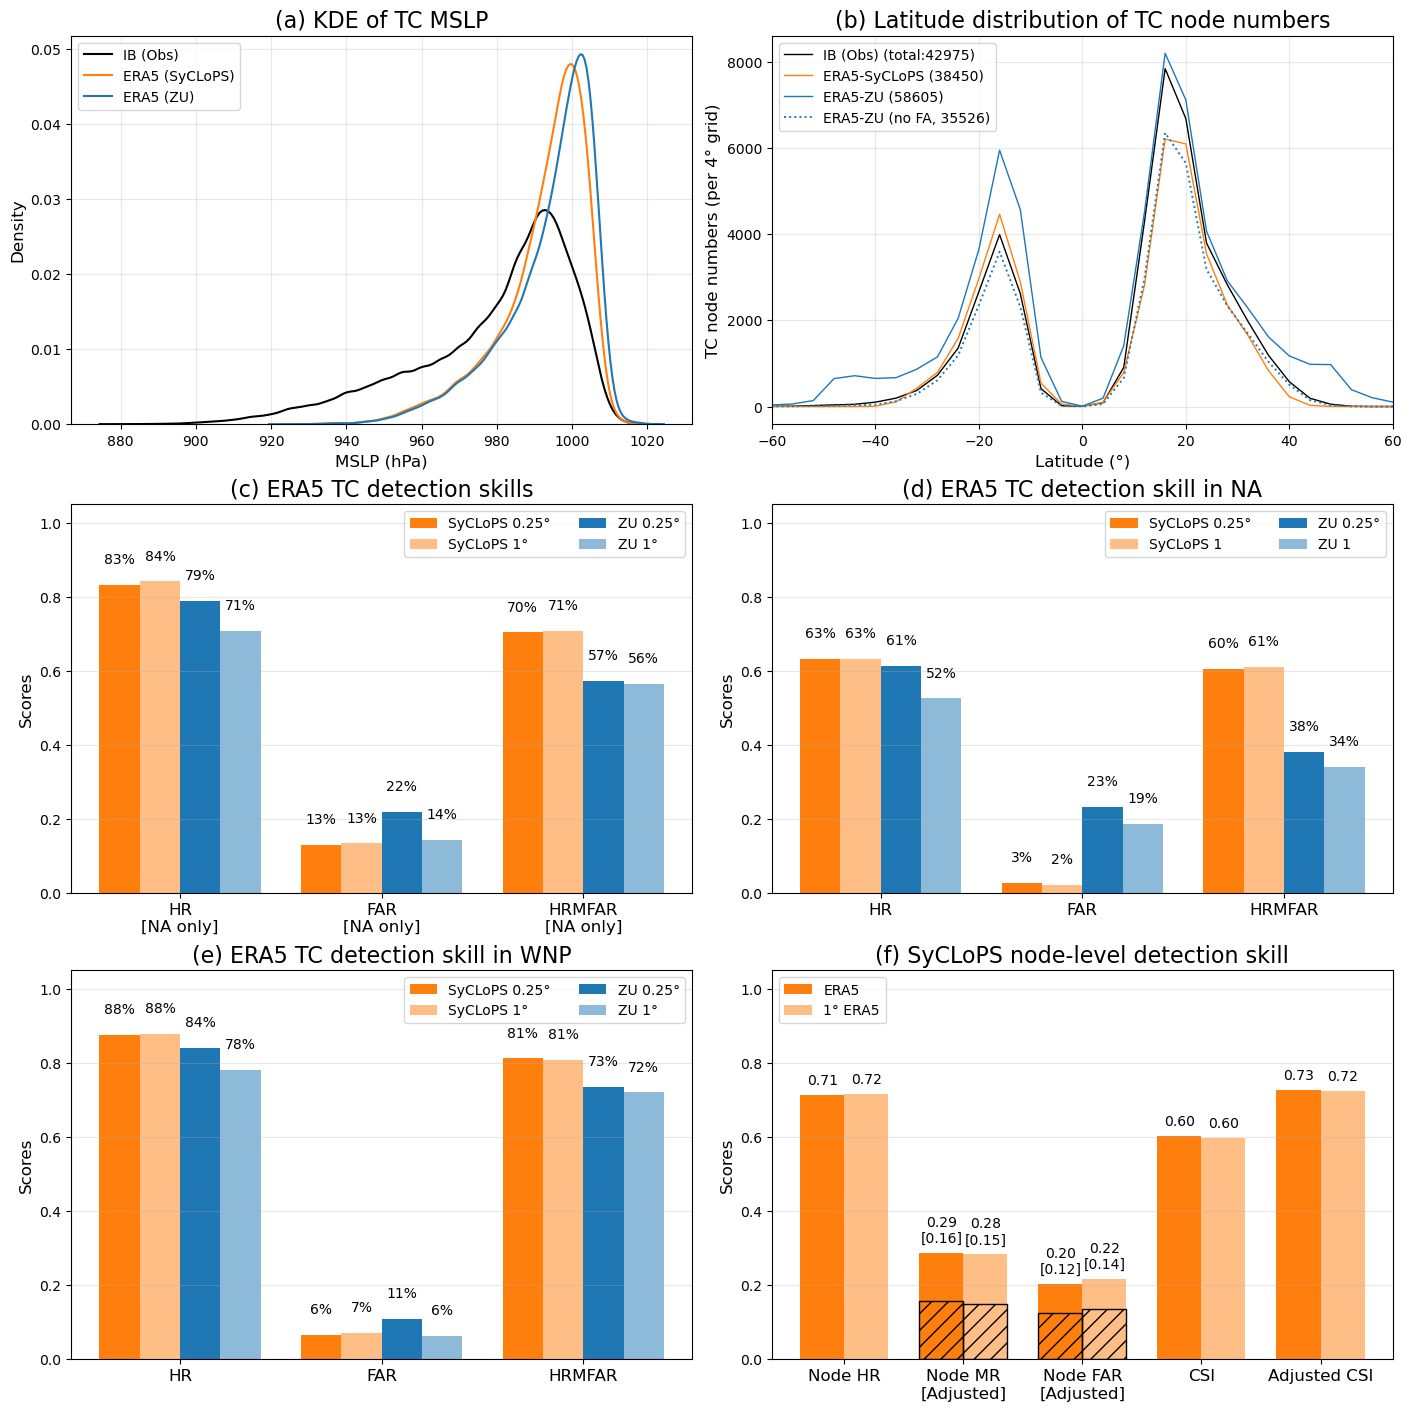

In [ ]:
# Plot Figure 2
#0.25 degree data
New025_HR=0.832
New025_HR_NA=0.631; New025_HR_WP=0.876
Old025_HR=0.789
Old025_HR_NA=0.612; Old025_HR_WP=0.841

New025_FAR=0.129
New025_FAR_NA=0.0262; New025_FAR_WP=0.064
Old025_FAR=0.217
Old025_FAR_NA=0.231; Old025_FAR_WP=0.107

New025_HRMFAR=0.703
Old025_HRMFAR=0.572
New025_HRMFAR_NA=New025_HR_NA-New025_FAR_NA
Old025_HRMFAR_NA=Old025_HR_NA-Old025_FAR_NA
New025_HRMFAR_WP=New025_HR_WP-New025_FAR_WP
Old025_HRMFAR_WP=Old025_HR_WP-Old025_FAR_WP

New025_NC=38450
Old025_NC=58605
New025_NHR=0.713
New025_NHR_adj=0.130
New025_NFAR=0.203
New025_NFAR_adj=0.080
New025_CSI=0.603
New025_CSI_adj=0.727

#1.0 degree data
New10_HR=0.841
New10_HR_NA = 0.631; New10_HR_WP=0.878
Old10_HR=0.708
Old10_HR_NA =0.525; Old10_HR_WP=0.782

New10_FAR=0.133
New10_FAR_NA=0.021; New10_FAR_WP=0.070
Old10_FAR=0.143
Old10_FAR_NA=0.186; Old10_FAR_WP=0.062

New10_HRMFAR=0.708
Old10_HRMFAR=0.565
New10_HRMFAR_NA=New10_HR_NA-New10_FAR_NA
Old10_HRMFAR_NA=Old10_HR_NA-Old10_FAR_NA
New10_HRMFAR_WP=New10_HR_WP-New10_FAR_WP
Old10_HRMFAR_WP=Old10_HR_WP-Old10_FAR_WP

New10_NC=39379
Old10_NC=48829
New10_NHR=0.717
New10_NHR_adj=0.136
New10_NFAR=0.217
New10_NFAR_adj=0.081
New10_CSI=0.598
New10_CSI_adj=0.725


fig = plt.figure(figsize=(14,14),layout='constrained')
ax = fig.add_subplot(3, 2, 1)
mslp_era5 = (dfsize['era5']['MSLP'] / 100.0)
mslp_era5o = (dfo_tc['era5o']['MSLP'] / 100.0)
mslp_ib = dfib[dfib.WMO_PRES>0]['WMO_PRES']

sns.kdeplot(mslp_ib, ax=ax, label='IB (Obs)', fill=False, lw=1.5 , color='k')
sns.kdeplot(mslp_era5, ax=ax, label='ERA5 (SyCLoPS)', fill=False, lw=1.5, color='tab:orange')
sns.kdeplot(mslp_era5o, ax=ax, label='ERA5 (ZU)', fill=False, lw=1.5, color='tab:blue')

ax.set_xlabel('MSLP (hPa)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('(a) KDE of TC MSLP', fontsize=16)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = fig.add_subplot(3, 2, 2)
# Total counts (4° bins) — plot as curves for era5 and era5deg1 TC nodes
bins = np.arange(-90, 90 + 4, 4)
mid = (bins[:-1] + bins[1:]) / 2

df_e5 = dfsize['era5']
df_e5d1 = dfsize['era5deg1']
df_ero = dfo_tc['era5o']
df_e5d1o = dfo_tc['era5deg1o']

counts_e5, _ = np.histogram(df_e5['LAT'].values, bins=bins)
counts_e5d1, _ = np.histogram(df_e5d1['LAT'].values, bins=bins)
counts_e5o, _ = np.histogram(df_ero['LAT'].values, bins=bins)
counts_e5d1o, _ = np.histogram(df_e5d1o['LAT'].values, bins=bins)
counts_ib, _ = np.histogram(dfib['LAT'].values, bins=bins)
counts_e5oadj, _ = np.histogram(df_ero['LAT'][df_ero.FA==0].values, bins=bins)
counts_e5d1oadj, _ = np.histogram(df_e5d1o['LAT'][df_e5d1o.FA==0].values, bins=bins)

# small moving-average smoothing for nicer curves
def smooth(arr, window=3):
    if window <= 1:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

s_e5 = smooth(counts_e5, window=0)
s_e5d1 = smooth(counts_e5d1, window=0)
s_e5o = smooth(counts_e5o, window=0)
s_e5d1o = smooth(counts_e5d1o, window=0)
s_ib = smooth(counts_ib, window=0)
s_e5oadj = smooth(counts_e5oadj, window=0)
#s_e5d1oadj = smooth(counts_e5d1oadj, window=3)

ax.plot(mid, s_ib, color='k', lw=1, label=f'IB (Obs) (total:{int(counts_ib.sum())})')
ax.plot(mid, s_e5, color='tab:orange', lw=1, label=f'ERA5-SyCLoPS ({int(counts_e5.sum())})')
#ax.plot(mid, s_e5d1, color='tab:orange', lw=1, label=f'1$\degree$ ERA5 (total:{int(counts_e5d1.sum())})')
ax.plot(mid, s_e5o, color='tab:blue', lw=1, label=f'ERA5-ZU ({int(counts_e5o.sum())})')
#ax.plot(mid, s_e5d1o, color='tab:blue', lw=1, ls='dashdot', label=f'1$\degree$ ERA5-ZU ({int(counts_e5d1o.sum())})')
ax.plot(mid, s_e5oadj, color='tab:blue', lw=1.4, ls='dotted', label=f'ERA5-ZU (no FA, {int(counts_e5oadj.sum())})')
#ax.plot(mid, s_e5d1oadj, color='tab:orange', lw=1, ls='dashdot', label=f'1$\degree$ ERA5-ZU (no FA, {int(counts_e5d1oadj.sum())})')

ax.set_xlabel('Latitude (°)', fontsize=12)
ax.set_ylabel('TC node numbers (per 4° grid)', fontsize=12)
ax.set_title('(b) Latitude distribution of TC node numbers', fontsize=16)
ax.set_xlim(-60, 60)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)

ax = fig.add_subplot(3, 2, 3)
# plot 1.0° data alongside the 0.25° bars plotted below
metrics = ['HR\n[NA only]', 'FAR\n[NA only]', 'HRMFAR\n[NA only]']
x = np.arange(len(metrics))

# choose a width for the 1.0° bars (slightly narrower so groups fit nicely)
New025_vals = [New025_HR, New025_FAR, New025_HRMFAR]
Old025_vals = [Old025_HR, Old025_FAR, Old025_HRMFAR]
New10_vals = [New10_HR, New10_FAR, New10_HRMFAR]
Old10_vals = [Old10_HR, Old10_FAR, Old10_HRMFAR]

width = 0.2
bars1 = ax.bar(x - 1.5*width, New025_vals, width, label='SyCLoPS 0.25°', color='tab:orange')
bars2 = ax.bar(x - 0.5*width, New10_vals, width, label='SyCLoPS 1°', color='tab:orange', alpha=0.5)
bars3 = ax.bar(x + 0.5*width, Old025_vals, width, label='ZU 0.25°', color='tab:blue')
bars4 = ax.bar(x + 1.5*width, Old10_vals, width, label='ZU 1°', color='tab:blue', alpha=0.5)


for bar_group1 in (bars1, bars2, bars3, bars4):
    for i, bar1 in enumerate(bar_group1):
        h1 = bar1.get_height()
        ax.text(bar1.get_x() + bar1.get_width() / 2, h1 + 0.05, f'{h1*100:.0f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('(c) ERA5 TC detection skills', fontsize=16)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=10, ncol=2)

ax = fig.add_subplot(3, 2, 4)
# plot 1.0° data alongside the 0.25° bars plotted below
metrics = ['HR', 'FAR', 'HRMFAR']
x = np.arange(len(metrics))

New025_NA = [New025_HR_NA, New025_FAR_NA, New025_HRMFAR_NA]
Old025_NA = [Old025_HR_NA, Old025_FAR_NA, Old025_HRMFAR_NA]
New10_NA = [New10_HR_NA, New10_FAR_NA, New10_HRMFAR_NA]
Old10_NA = [Old10_HR_NA, Old10_FAR_NA, Old10_HRMFAR_NA]

width = 0.2
bars1 = ax.bar(x - 1.5*width, New025_NA, width, label='SyCLoPS 0.25°', color='tab:orange')
bars2 = ax.bar(x - 0.5*width, New10_NA, width, label='SyCLoPS 1', color='tab:orange', alpha=0.5)
bars3 = ax.bar(x + 0.5*width, Old025_NA, width, label='ZU 0.25°', color='tab:blue')
bars4 = ax.bar(x + 1.5*width, Old10_NA, width, label='ZU 1', color='tab:blue', alpha=0.5)


for bar_group1 in (bars1, bars2, bars3, bars4):
    for i, bar1 in enumerate(bar_group1):
        h1 = bar1.get_height()
        ax.text(bar1.get_x() + bar1.get_width() / 2, h1 + 0.05, f'{h1*100:.0f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('(d) ERA5 TC detection skill in NA', fontsize=16)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=10, ncol=2)

ax = fig.add_subplot(3, 2, 5)
# plot 1.0° data alongside the 0.25° bars plotted below
metrics = ['HR', 'FAR', 'HRMFAR']
x = np.arange(len(metrics))
New025_WP = [New025_HR_WP, New025_FAR_WP, New025_HRMFAR_WP]
Old025_WP = [Old025_HR_WP, Old025_FAR_WP, Old025_HRMFAR_WP]
New10_WP = [New10_HR_WP, New10_FAR_WP, New10_HRMFAR_WP]
Old10_WP = [Old10_HR_WP, Old10_FAR_WP, Old10_HRMFAR_WP]

width = 0.2
bars1 = ax.bar(x - 1.5*width, New025_WP, width, label='SyCLoPS 0.25°', color='tab:orange')
bars2 = ax.bar(x - 0.5*width, New10_WP, width, label='SyCLoPS 1°', color='tab:orange', alpha=0.5)
bars3 = ax.bar(x + 0.5*width, Old025_WP, width, label='ZU 0.25°', color='tab:blue')
bars4 = ax.bar(x + 1.5*width, Old10_WP, width, label='ZU 1°', color='tab:blue', alpha=0.5)


for bar_group1 in (bars1, bars2, bars3, bars4):
    for i, bar1 in enumerate(bar_group1):
        h1 = bar1.get_height()
        ax.text(bar1.get_x() + bar1.get_width() / 2, h1 + 0.05, f'{h1*100:.0f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics,fontsize=12)
ax.set_ylabel('Scores',fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('(e) ERA5 TC detection skill in WNP', fontsize=16)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=10, ncol=2)

ax = fig.add_subplot(3, 2, 6)
# Plot node metrics as grouped bar plots for new methods only (raw + adjusted)
metrics = ['Node HR', 'Node MR\n[Adjusted]', 'Node FAR\n[Adjusted]', 'CSI', 'Adjusted CSI']
x = np.arange(5)

def g(name, default=np.nan):
    return globals().get(name, default)

# gather values for new methods (fall back to nan if missing)
New025_node     = [g('New025_NHR'), 1-g('New025_NHR'),g('New025_NFAR'), g('New025_CSI'),g('New025_CSI_adj')]
New025_node_adj = [np.nan, 1-g('New025_NHR')-g('New025_NHR_adj'), g('New025_NFAR')-g('New025_NFAR_adj'), np.nan, np.nan]
New10_node      = [g('New10_NHR'), 1-g('New10_NHR'), g('New10_NFAR'), g('New10_CSI'), g('New10_CSI_adj')]
New10_node_adj  = [np.nan, 1-g('New10_NHR')-g('New10_NHR_adj'), g('New10_NFAR')-g('New10_NFAR_adj'), np.nan, np.nan]

width = 0.37
# raw bars for new methods
bars1 = ax.bar(x - width/2, New025_node, width, label='ERA5', color='tab:orange')
bars2 = ax.bar(x + width/2, New10_node,  width, label='1° ERA5',  color='tab:orange',alpha=0.5)

# adjusted bars (narrower, hollow for contrast)
ax.bar(x - width/2, New025_node_adj, width, edgecolor='k', facecolor='none',hatch='//')
ax.bar(x + width/2, New10_node_adj,  width, edgecolor='k', facecolor='none',hatch='//')

# annotate raw bar values and, when present, the adjusted value on the line underneath
adj_lists = [New025_node_adj, New10_node_adj]
for bars, adj in zip((bars1, bars2), adj_lists):
    for i, bar in enumerate(bars):
        h = bar.get_height()
        # get adjusted value for this metric (may be 0 or nan if not applicable)
        adj_v = adj[i]
        if not np.isnan(adj_v) and adj_v > 0:
            label = f'{h:.2f}\n[{adj_v:.2f}]'
        else:
            label = f'{h:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, label,
                ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('(f) SyCLoPS node-level detection skill', fontsize=16)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

fig.savefig('../figures/figure3.jpg', dpi=500, bbox_inches='tight')